In [1]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz4"
NOBJ = 5
K = 10
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [2]:
MU = 1000
NGEN = 300
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [3]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz4, obj=NOBJ, alpha=100)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [4]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        pop_comp = pop[:(int)(MU/(1 << NOBJ))]
        hv_val = hypervolume(pop_comp, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        approx_front_comp = approx_front[:(int)(MU/(1 << NOBJ))]
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front_comp)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [5]:
pop, logbook = main()

gen	evals	std                                                     	min                                                                               	avg                                                     	max                                                     	hypervolume	igd_plus
0  	1000 	[0.29316823 0.16333331 0.16504088 0.15053929 0.17217091]	[1.74717321e-002 1.97626258e-322 3.53822669e-276 0.00000000e+000
 1.90954902e-247]	[1.79611193 0.02533895 0.02252007 0.02179152 0.02467191]	[2.58480744 1.93621354 2.12557814 2.19587952 1.98494157]	           	        
1  	1000 	[0.32962758 0.21837629 0.21624276 0.2138378  0.22633386]	[1.74717321e-002 1.97626258e-322 0.00000000e+000 0.00000000e+000
 0.00000000e+000]	[1.68749256 0.03585541 0.0327607  0.035257   0.03560169]	[2.46584302 1.99914629 2.12557814 2.19587952 2.25251244]	0.0671614  	0.64231 
2  	1000 	[0.39818046 0.29136955 0.26967939 0.29481603 0.29226889]	[1.72568788e-002 1.97626258e-322 0.00000000e+000 0.00000000e+000
 0.00000000e+

[0.8394848881810285, 0.9735857744483403, 0.9958380310014745, 0.9949028993523921, 0.46640648441917154, 0.5059717999598404, 0.4985357411512226, 0.5181964926339688, 0.5132339664724238, 0.49256371942092647, 0.4816070195808457, 0.5108174084854004, 0.5680140231153712, 0.4225751713003022]
[0.9770484568995453, 0.9109350746765835, 0.9801830086536061, 0.9975501516721098, 0.4292292822472412, 0.48309817262811455, 0.5170719989191337, 0.43330270953009764, 0.6142377595088467, 0.4895023584543156, 0.5109036918478042, 0.4927663531234665, 0.5014847230948392, 0.5279706296328784]
[0.9892415764923995, 0.9944178482410578, 0.9928084404789544, 0.983217284440442, 0.4986528995143597, 0.5138827090498094, 0.5225899395081431, 0.47250476198605645, 0.49451867165591257, 0.45666112901367084, 0.48880297525942923, 0.4884460822136155, 0.5110573835401528, 0.48585310927034614]
[0.9736835673765986, 0.9933155405638663, 0.9087265524107953, 0.9989478415537594, 0.4846234039725239, 0.4709243843386958, 0.48291272345788516, 0.48735

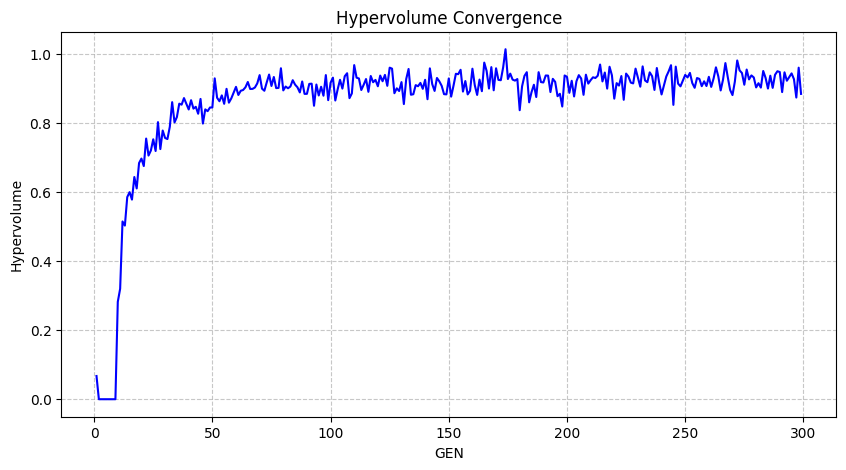

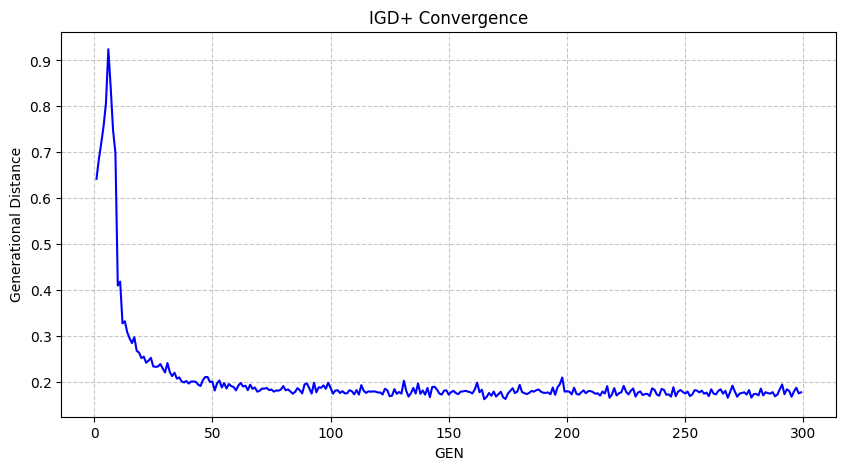

In [6]:
import matplotlib.pyplot as plt


for ind in pop:
   print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()